# Coin Detection System - Computer Vision Project
---

## Overview
This notebook detects and classifies coins in images using traditional computer vision techniques:
- **Circular Hough Transform** for circle detection
- **Size and Color analysis** for classification
- **No currency assumptions** - works for any coins worldwide

## Algorithm Pipeline
1. Load and preprocess image (grayscale + blur)
2. Detect circular shapes using Hough Transform
3. Extract features (radius, color) for each coin
4. Classify by size category and color
5. Group similar coins together
6. Visualize and summarize results

## Team Members
| Name                | ID      |
|---------------------|---------|
| Ahmed Hazem         | 22P0226 |
| Karim Hatem         | 22P0153 |
| Youssef Mostafa     | 22P0047 |
| Mostafa Foaad       | 22P0077 |
| AbdElRahman Mostafa | 22P0053 |

## Section 0 : Importing Libraries

In [136]:
import cv2
import os
import numpy as np
import math
from collections import Counter
import matplotlib.pyplot as plt

print("Libraries loaded successfully!")
print(f"OpenCV version: {cv2.__version__}")

Libraries loaded successfully!
OpenCV version: 4.13.0


## Section 1 : Color Classification Functions
Defines coin colors (Silver, Gold, Copper, etc.)

Classify color based on HSV values

Parameters: hsv_color : tuple (Hue, Saturation, Value) values

Returns: (str) Color category name

In [137]:
# Section 1
def get_color_name(hsv_color):
    h, s, v = hsv_color

    # Very dark/black coins (some tokens, old coins)
    if v < 40:
        return "Dark/Black"

    # Silver/White coins (most modern coins: US quarters, dimes, Euro cents)
    if v > 180 and s < 40:
        return "Silver"

    # Gold/Brass coins (US dollars, some Euro coins, Arabic coins)
    if 15 <= h <= 35 and s > 40 and v > 100:
        return "Gold/Brass"

    # Copper/Bronze coins (US pennies, UK pennies, some Euro cents)
    if (h <= 15 or h >= 160) and s > 50 and v > 70:
        return "Copper/Bronze"

    # Nickel/Silver-gray tones (US nickels, some Euro coins)
    if 20 <= h <= 80 and s < 50 and v > 100:
        return "Nickel/Silver"

    # Yellowish coins (some commemorative coins, older gold-colored)
    if 25 <= h <= 45 and s > 40 and v > 120:
        return "Yellow/Gold"

    # Reddish-brown coins (very old copper coins, some tokens)
    if h <= 10 and s > 60 and 50 < v < 120:
        return "Reddish-Brown"

    # Gray coins (worn silver coins, some base metals)
    if s < 30 and 80 < v < 180:
        return "Gray"

    # Default for unusual coins
    return "Colored"

# Test the color function
test_colors = [
    (30, 100, 200),  # Should be Gold/Brass
    (10, 80, 150),   # Should be Copper/Bronze
    (60, 20, 220),   # Should be Silver
]

for hsv in test_colors:
    print(f"HSV {hsv} -> {get_color_name(hsv)}")

HSV (30, 100, 200) -> Gold/Brass
HSV (10, 80, 150) -> Copper/Bronze
HSV (60, 20, 220) -> Silver


## Section 2 : Size Classification

Size categories based on radius in pixels (adjustable for your image scale):

Classify coin size based on radius in pixels

Parameters: radius_pixels : (int) Radius of coin in pixels

Returns: (str) : Size category name

| Category | Radius Range |
|----------|--------------|
| Very Small | < 18 px |
| Small | 18-27 px |
| Medium | 28-37 px |
| Large | 38-49 px |
| Very Large | ≥ 50 px |

In [138]:
# Section 2 - Mathematical Dynamic Sizing
def get_dynamic_thresholds(coins_data):
    """Calculates boundaries based on the distribution of sizes in the current image."""
    if not coins_data:
        return None

    # We use radius for thresholds
    radii = [c['radius'] for c in coins_data]
    r_min, r_max = min(radii), max(radii)

    # Divide the spread into 3 equal mathematical intervals
    step = (r_max - r_min) / 3
    return {
        "small_limit": r_min + step,
        "medium_limit": r_min + 2 * step
    }

def get_size_category(radius, thresholds):
    """Assigns category based on the image's dynamic math."""
    if not thresholds:
        return "Unknown"
    if radius < thresholds["small_limit"]:
        return "Small"
    elif radius < thresholds["medium_limit"]:
        return "Medium"
    else:
        return "Large"

## Section 3 : Coin Detection (Hough Circle Transform)

Detects circular shapes in the image using Hough Circle Transform.

Parameters: image_path : str (path to image file)

Returns: (original_image, circles) or (None, None) if detection fails

Hough Parameters:
- dp=1 : Resolution ratio
- minDist=50 : Minimum distance between circle centers
- param1=100 : Edge detection threshold
- param2=30 : Circle detection sensitivity (lower = more circles)
- minRadius=10 : Minimum coin radius
- maxRadius=100 : Maximum coin radius

In [139]:
# Section 3 - Expanded Multi-Pass Median-Filtered Hough Detection
import cv2
import numpy as np
import os

def standardize_image(image, target_width=800):
    """Resizes an image to a fixed width while maintaining aspect ratio."""
    h, w = image.shape[:2]
    scale = target_width / w
    target_height = int(h * scale)
    inter = cv2.INTER_AREA if scale < 1.0 else cv2.INTER_LINEAR
    return cv2.resize(image, (target_width, target_height), interpolation=inter)

def circles_overlap(c1, c2, margin=0.2):
    """Checks if two circles overlap significantly to prevent duplicate detections."""
    x1, y1, r1 = c1
    x2, y2, r2 = c2
    dist = np.sqrt((x1 - x2)**2 + (y1 - y2)**2)
    return dist < (r1 + r2) * (1.0 - margin)

def detect_coins(image_path):
    img = cv2.imread(image_path)
    if img is None:
        return None, None

    # 1. Standardize dimensions
    img = standardize_image(img, target_width=800)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # 2. Strong Median Blur dissolves background table textures while preserving solid coin edges
    blurred = cv2.medianBlur(gray, 13)
    blurred = cv2.GaussianBlur(blurred, (5, 5), 0)

    valid_circles = []

    # --- PASS 1: Wide-Range & Close-up Search ---
    # maxRadius expanded to 180 catches macro/zoomed shots seamlessly (Fixes Coins_6 and Coins_9)
    circles_pass1 = cv2.HoughCircles(
        blurred, 
        cv2.HOUGH_GRADIENT, 
        dp=1.0, 
        minDist=30, 
        param1=100, 
        param2=30,       # Solid confidence baseline for clear metallic boundaries
        minRadius=12, 
        maxRadius=180    # Expanded upper limit permits diameters up to 360px
    )

    if circles_pass1 is not None:
        for c in np.round(circles_pass1[0, :]).astype("int"):
            valid_circles.append(c.tolist())

    # --- PASS 2: High Sensitivity Search ---
    # Targets tiny, tightly clustered, or faint coins that missed the primary pass
    circles_pass2 = cv2.HoughCircles(
        blurred, 
        cv2.HOUGH_GRADIENT, 
        dp=1.0, 
        minDist=20,      # Tight allowance lets touching coins register independently
        param1=85,       # More sensitive edge detection threshold
        param2=24,       # Lower accumulator score accepts faint or shadowed boundaries
        minRadius=10,    # Catches distanced or physically smaller coins
        maxRadius=90     # Clamped lower to prevent background ghosting on sensitive settings
    )

    if circles_pass2 is not None:
        for c2 in np.round(circles_pass2[0, :]).astype("int"):
            is_duplicate = any(circles_overlap(c2, c1) for c1 in valid_circles)
            if not is_duplicate:
                valid_circles.append(c2.tolist())

    # --- PASS 3: Ultimate Rescue Fallback ---
    # Failsafe scan triggered only if the image yields 0 detections under standard passes.
    if not valid_circles:
        rescue_circles = cv2.HoughCircles(
            blurred, 
            cv2.HOUGH_GRADIENT, 
            dp=1.0, 
            minDist=20,
            param1=70,       # Highly forgiving edge search
            param2=20,       # Extremely low threshold to force detection in harsh conditions
            minRadius=10, 
            maxRadius=180
        )
        if rescue_circles is not None:
            for c3 in np.round(rescue_circles[0, :]).astype("int"):
                valid_circles.append(c3.tolist())

    print(f"Detected {len(valid_circles)} coins in {os.path.basename(image_path)}")
    return img, np.array(valid_circles) if valid_circles else None

## Section 4 : Feature Extraction

Extracts size and color features from each detected coin.

Parameters:
- original_image : numpy.ndarray (BGR image)
- circles : numpy.ndarray (detected circles)

Returns: list of dictionaries containing coin features (id, center, radius, diameter, color, size, etc.)

In [140]:
# Section 4 - Enhanced Feature Extraction
import math

def extract_coin_features(original_image, circles, thresholds):
    coin_features = []

    for i, (x, y, r) in enumerate(circles):
        # 1. Create a precise mask for the coin
        mask = np.zeros(original_image.shape[:2], dtype=np.uint8)
        cv2.circle(mask, (int(x), int(y)), int(r), 255, -1)

        # 2. Calculate color in HSV space
        mean_bgr = cv2.mean(original_image, mask=mask)[:3]
        mean_bgr_uint8 = np.uint8([[mean_bgr]])
        mean_hsv = cv2.cvtColor(mean_bgr_uint8, cv2.COLOR_BGR2HSV)[0][0]

        # 3. Build the feature dictionary with all expected keys
        coin_features.append({
            'id': i + 1,
            'center': (int(x), int(y)),
            'radius': int(r),
            'diameter_pixels': int(r * 2), # Required for print_summary
            'area_pixels': math.pi * (r ** 2),
            'color': get_color_name(mean_hsv),
            'size': get_size_category(r, thresholds), # Dynamic classification
            'bgr': mean_bgr,
            'hsv': mean_hsv
        })

    return coin_features

## Section 5 : Coin Grouping

Groups coins that share the same size category AND color.

Parameters: coins : list (coin features from Section 5)

Returns: list of groups with group ID, count, size, color, and average measurements

In [141]:
# Section 5 - Dynamic Grouping with Statistics
def group_similar_coins(coins):
    groups_dict = {}

    for coin in coins:
        # Group by the unique combination of Color and Dynamic Size
        group_key = f"{coin['color']}_{coin['size']}"

        if group_key not in groups_dict:
            groups_dict[group_key] = {
                'id': len(groups_dict) + 1,
                'count': 0,
                'coins': [],
                'color': coin['color'],
                'size': coin['size']
            }

        groups_dict[group_key]['count'] += 1
        groups_dict[group_key]['coins'].append(coin)

    # Calculate statistical averages for each group
    final_groups = []
    for key in groups_dict:
        group = groups_dict[key]
        group['avg_radius'] = np.mean([c['radius'] for c in group['coins']])
        group['avg_diameter'] = np.mean([c['diameter_pixels'] for c in group['coins']])
        final_groups.append(group)

    # Sort groups by coin count (most frequent first)
    final_groups.sort(key=lambda x: x['count'], reverse=True)
    return final_groups

## Section 6 : Image Annotation

Draws results on the image. Circle colors are chosen from realistic metallic/coin colors (no pink, magenta, cyan, etc.)

Parameters:
- image : numpy.ndarray (image to annotate)
- coins : list (coin features)
- groups : list (coin groups)

Returns: annotated image

In [142]:
# Section 6
def annotate_image(image, coins, groups):
    # Realistic colors that might appear on coins or currency
    group_colors = [
        (192, 192, 192),  # Silver
        (218, 165, 32),   # Goldenrod
        (205, 127, 50),   # Copper
        (169, 169, 169),  # Dark Gray
        (255, 215, 0),    # Gold
        (210, 105, 30),   # Bronze
        (128, 128, 128),  # Gray
        (238, 232, 170),  # Pale Goldenrod
        (184, 115, 51),   # Peru (brownish-gold)
        (192, 192, 192),  # Light Silver
    ]

    group_color_map = {}
    for i, group in enumerate(groups):
        group_color_map[group['id']] = group_colors[i % len(group_colors)]

    for coin in coins:
        x, y = coin['center']
        r = coin['radius']

        group_id = None
        for group in groups:
            if coin in group['coins']:
                group_id = group['id']
                break

        if group_id:
            color = group_color_map[group_id]

            cv2.circle(image, (x, y), r, color, 4)
            cv2.circle(image, (x, y), 3, color, -1)

            label = f"G{group_id}: {coin['color']}, {coin['size']}"
            text_x, text_y = x - r, y - r - 10

            (text_w, text_h), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.6, 2)
            cv2.rectangle(image, (text_x - 5, text_y - text_h - 5),
                         (text_x + text_w + 5, text_y + 5), (0, 0, 0), -1)
            cv2.rectangle(image, (text_x - 5, text_y - text_h - 5),
                         (text_x + text_w + 5, text_y + 5), color, 2)
            cv2.putText(image, label, (text_x, text_y),
                       cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 255, 255), 2)

    return image

## Section 7 : Results Summary

Prints formatted summary to console and creates statistics image.

Parameters: coins, groups (from previous sections)

Returns: None (prints to console and saves image)

In [143]:
# Section 7
def print_summary(coins, groups):
    print("\n" + "="*60)
    print("COIN DETECTION & CLASSIFICATION SUMMARY")
    print("="*60)
    print(f"\n📊 TOTAL: {len(coins)} coins detected\n")

    print("📋 CLASSIFICATION BY GROUPS:")
    print("-"*60)
    for group in groups:
        print(f"\n GROUP {group['id']}: {group['count']} coins")
        print(f"      Size: {group['size']}")
        print(f"      Color: {group['color']}")
        print(f"      Avg Diameter: {group['avg_diameter']:.1f} pixels")
        print(f"      Coin IDs: {[c['id'] for c in group['coins']]}")

    print("\n" + "-"*60)
    color_counts = Counter([c['color'] for c in coins])
    print("\n🎨 By Color:")
    for color, count in color_counts.most_common():
        print(f"   {color:15s}: {count:2d} coins ({count/len(coins)*100:.1f}%)")

    size_counts = Counter([c['size'] for c in coins])
    print("\n📏 By Size:")
    for size, count in size_counts.most_common():
        print(f"   {size:12s}: {count:2d} coins ({count/len(coins)*100:.1f}%)")

    print("\n" + "="*60)

def create_stats_image(coins, groups):
    stats_img = np.zeros((600, 500, 3), dtype=np.uint8)
    y = 50

    cv2.putText(stats_img, "CLASSIFICATION STATISTICS", (50, y),
               cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)
    y += 70

    cv2.putText(stats_img, f"Total Coins: {len(coins)}", (50, y),
               cv2.FONT_HERSHEY_SIMPLEX, 0.7, (100, 255, 100), 2)
    y += 40

    cv2.putText(stats_img, "Groups Found:", (50, y),
               cv2.FONT_HERSHEY_SIMPLEX, 0.6, (255, 200, 100), 2)
    y += 30

    for group in groups[:8]:
        text = f"Group {group['id']}: {group['count']} coins - {group['color']}, {group['size']}"
        cv2.putText(stats_img, text, (70, y),
                   cv2.FONT_HERSHEY_SIMPLEX, 0.5, (200, 200, 200), 1)
        y += 25

    return stats_img

## Section 8

--- Processing: Coins_1.jpg ---
Detected 29 coins in Coins_1.jpg

COIN DETECTION & CLASSIFICATION SUMMARY

📊 TOTAL: 29 coins detected

📋 CLASSIFICATION BY GROUPS:
------------------------------------------------------------

 GROUP 1: 8 coins
      Size: Medium
      Color: Gold/Brass
      Avg Diameter: 114.2 pixels
      Coin IDs: [1, 3, 5, 8, 12, 13, 19, 26]

 GROUP 8: 4 coins
      Size: Small
      Color: Copper/Bronze
      Avg Diameter: 85.5 pixels
      Coin IDs: [14, 20, 21, 25]

 GROUP 4: 3 coins
      Size: Medium
      Color: Silver
      Avg Diameter: 114.0 pixels
      Coin IDs: [6, 18, 24]

 GROUP 2: 2 coins
      Size: Large
      Color: Gold/Brass
      Avg Diameter: 127.0 pixels
      Coin IDs: [2, 15]

 GROUP 3: 2 coins
      Size: Large
      Color: Nickel/Silver
      Avg Diameter: 141.0 pixels
      Coin IDs: [4, 11]

 GROUP 6: 2 coins
      Size: Large
      Color: Silver
      Avg Diameter: 135.0 pixels
      Coin IDs: [9, 17]

 GROUP 7: 2 coins
      Size: Medi

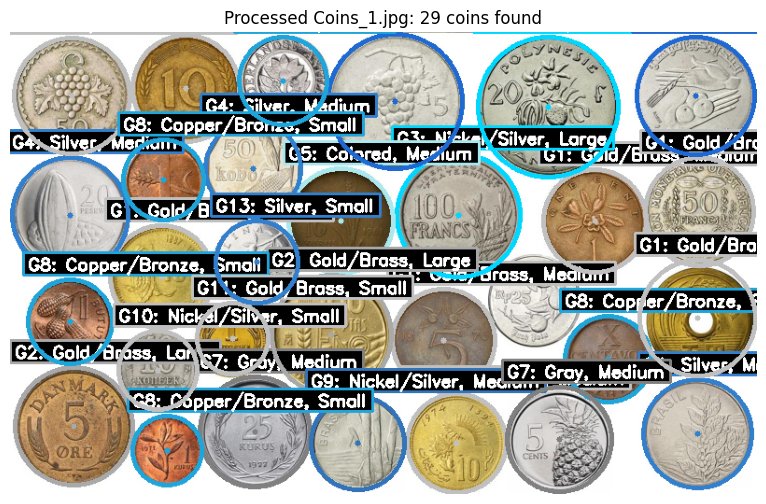

--- Processing: Coins_10.jpg ---
Detected 6 coins in Coins_10.jpg

COIN DETECTION & CLASSIFICATION SUMMARY

📊 TOTAL: 6 coins detected

📋 CLASSIFICATION BY GROUPS:
------------------------------------------------------------

 GROUP 1: 1 coins
      Size: Large
      Color: Silver
      Avg Diameter: 172.0 pixels
      Coin IDs: [1]

 GROUP 2: 1 coins
      Size: Large
      Color: Reddish-Brown
      Avg Diameter: 178.0 pixels
      Coin IDs: [2]

 GROUP 3: 1 coins
      Size: Large
      Color: Nickel/Silver
      Avg Diameter: 168.0 pixels
      Coin IDs: [3]

 GROUP 4: 1 coins
      Size: Small
      Color: Gold/Brass
      Avg Diameter: 148.0 pixels
      Coin IDs: [4]

 GROUP 5: 1 coins
      Size: Large
      Color: Gold/Brass
      Avg Diameter: 170.0 pixels
      Coin IDs: [5]

 GROUP 6: 1 coins
      Size: Small
      Color: Gray
      Avg Diameter: 142.0 pixels
      Coin IDs: [6]

------------------------------------------------------------

🎨 By Color:
   Gold/Brass     :  

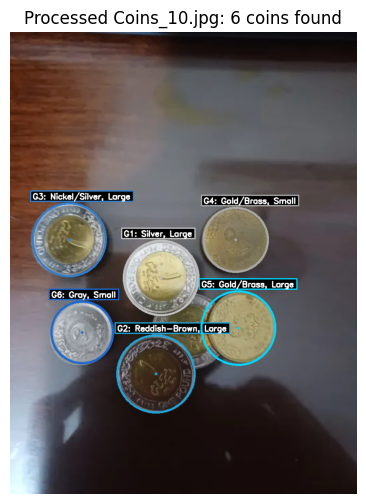

--- Processing: Coins_2.jpg ---
Detected 62 coins in Coins_2.jpg

COIN DETECTION & CLASSIFICATION SUMMARY

📊 TOTAL: 62 coins detected

📋 CLASSIFICATION BY GROUPS:
------------------------------------------------------------

 GROUP 1: 19 coins
      Size: Medium
      Color: Gold/Brass
      Avg Diameter: 95.5 pixels
      Coin IDs: [1, 5, 6, 7, 9, 10, 13, 14, 19, 21, 27, 31, 33, 34, 41, 42, 45, 46, 57]

 GROUP 3: 11 coins
      Size: Large
      Color: Gold/Brass
      Avg Diameter: 115.3 pixels
      Coin IDs: [3, 4, 12, 20, 23, 25, 37, 39, 44, 49, 60]

 GROUP 10: 6 coins
      Size: Small
      Color: Gold/Brass
      Avg Diameter: 73.0 pixels
      Coin IDs: [35, 47, 54, 55, 58, 62]

 GROUP 5: 5 coins
      Size: Large
      Color: Silver
      Avg Diameter: 115.2 pixels
      Coin IDs: [16, 18, 22, 24, 61]

 GROUP 2: 4 coins
      Size: Large
      Color: Nickel/Silver
      Avg Diameter: 112.0 pixels
      Coin IDs: [2, 8, 11, 29]

 GROUP 7: 4 coins
      Size: Medium
      Color

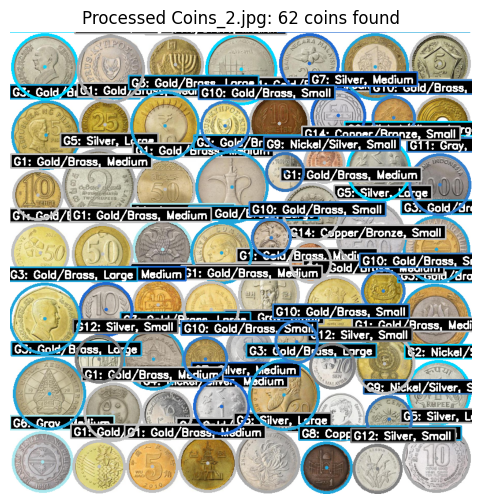

--- Processing: Coins_3.jpg ---
Detected 24 coins in Coins_3.jpg

COIN DETECTION & CLASSIFICATION SUMMARY

📊 TOTAL: 24 coins detected

📋 CLASSIFICATION BY GROUPS:
------------------------------------------------------------

 GROUP 3: 4 coins
      Size: Large
      Color: Silver
      Avg Diameter: 127.5 pixels
      Coin IDs: [3, 4, 19, 20]

 GROUP 1: 3 coins
      Size: Medium
      Color: Copper/Bronze
      Avg Diameter: 104.0 pixels
      Coin IDs: [1, 8, 15]

 GROUP 2: 3 coins
      Size: Large
      Color: Gold/Brass
      Avg Diameter: 131.3 pixels
      Coin IDs: [2, 5, 11]

 GROUP 4: 3 coins
      Size: Small
      Color: Gold/Brass
      Avg Diameter: 96.0 pixels
      Coin IDs: [6, 9, 23]

 GROUP 5: 2 coins
      Size: Medium
      Color: Gray
      Avg Diameter: 112.0 pixels
      Coin IDs: [7, 13]

 GROUP 6: 2 coins
      Size: Medium
      Color: Gold/Brass
      Avg Diameter: 112.0 pixels
      Coin IDs: [10, 24]

 GROUP 7: 2 coins
      Size: Medium
      Color: Silve

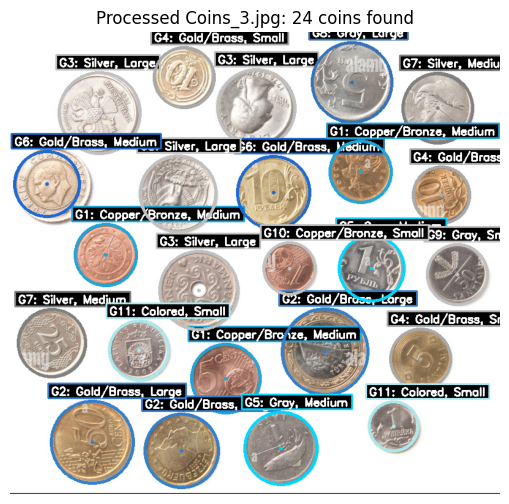

--- Processing: Coins_4.jpg ---
Detected 28 coins in Coins_4.jpg

COIN DETECTION & CLASSIFICATION SUMMARY

📊 TOTAL: 28 coins detected

📋 CLASSIFICATION BY GROUPS:
------------------------------------------------------------

 GROUP 2: 8 coins
      Size: Small
      Color: Copper/Bronze
      Avg Diameter: 115.2 pixels
      Coin IDs: [2, 5, 12, 14, 19, 21, 27, 28]

 GROUP 6: 5 coins
      Size: Medium
      Color: Gray
      Avg Diameter: 136.4 pixels
      Coin IDs: [9, 11, 13, 15, 25]

 GROUP 4: 3 coins
      Size: Medium
      Color: Copper/Bronze
      Avg Diameter: 135.3 pixels
      Coin IDs: [4, 6, 8]

 GROUP 8: 3 coins
      Size: Small
      Color: Gold/Brass
      Avg Diameter: 110.0 pixels
      Coin IDs: [16, 17, 23]

 GROUP 9: 3 coins
      Size: Small
      Color: Gray
      Avg Diameter: 119.3 pixels
      Coin IDs: [18, 22, 26]

 GROUP 1: 1 coins
      Size: Medium
      Color: Gold/Brass
      Avg Diameter: 140.0 pixels
      Coin IDs: [1]

 GROUP 3: 1 coins
      Siz

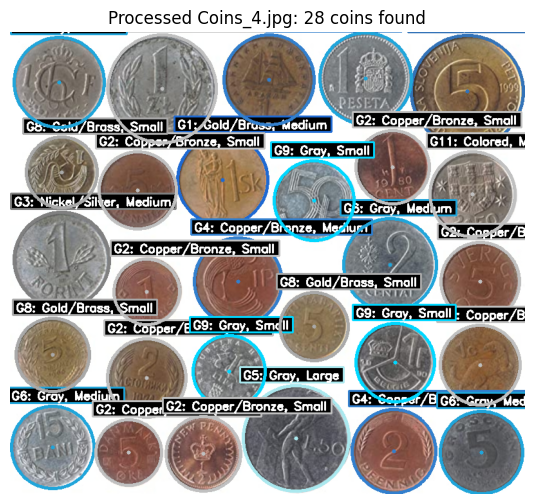

--- Processing: Coins_5.jpg ---
Detected 14 coins in Coins_5.jpg

COIN DETECTION & CLASSIFICATION SUMMARY

📊 TOTAL: 14 coins detected

📋 CLASSIFICATION BY GROUPS:
------------------------------------------------------------

 GROUP 2: 4 coins
      Size: Medium
      Color: Gold/Brass
      Avg Diameter: 204.5 pixels
      Coin IDs: [2, 4, 5, 7]

 GROUP 1: 3 coins
      Size: Large
      Color: Nickel/Silver
      Avg Diameter: 247.3 pixels
      Coin IDs: [1, 3, 9]

 GROUP 5: 3 coins
      Size: Small
      Color: Gold/Brass
      Avg Diameter: 136.0 pixels
      Coin IDs: [10, 13, 14]

 GROUP 4: 2 coins
      Size: Medium
      Color: Nickel/Silver
      Avg Diameter: 196.0 pixels
      Coin IDs: [8, 11]

 GROUP 3: 1 coins
      Size: Large
      Color: Gold/Brass
      Avg Diameter: 248.0 pixels
      Coin IDs: [6]

 GROUP 6: 1 coins
      Size: Medium
      Color: Gray
      Avg Diameter: 210.0 pixels
      Coin IDs: [12]

-----------------------------------------------------------

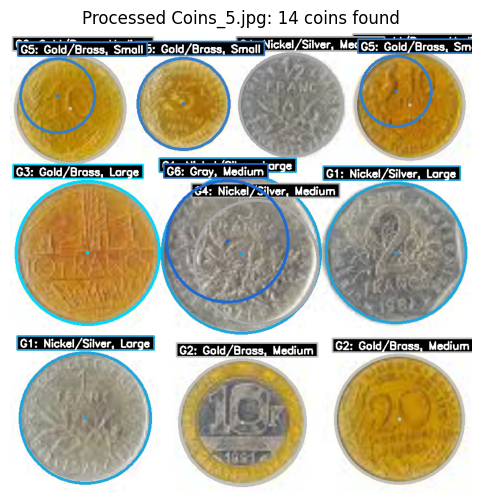

--- Processing: Coins_6.jpg ---
Detected 6 coins in Coins_6.jpg

COIN DETECTION & CLASSIFICATION SUMMARY

📊 TOTAL: 6 coins detected

📋 CLASSIFICATION BY GROUPS:
------------------------------------------------------------

 GROUP 3: 3 coins
      Size: Small
      Color: Silver
      Avg Diameter: 208.7 pixels
      Coin IDs: [3, 5, 6]

 GROUP 1: 1 coins
      Size: Medium
      Color: Gold/Brass
      Avg Diameter: 236.0 pixels
      Coin IDs: [1]

 GROUP 2: 1 coins
      Size: Large
      Color: Silver
      Avg Diameter: 280.0 pixels
      Coin IDs: [2]

 GROUP 4: 1 coins
      Size: Small
      Color: Gold/Brass
      Avg Diameter: 198.0 pixels
      Coin IDs: [4]

------------------------------------------------------------

🎨 By Color:
   Silver         :  4 coins (66.7%)
   Gold/Brass     :  2 coins (33.3%)

📏 By Size:
   Small       :  4 coins (66.7%)
   Medium      :  1 coins (16.7%)
   Large       :  1 coins (16.7%)

  ✓ Saved 6 cropped coins to output\Coins_6/


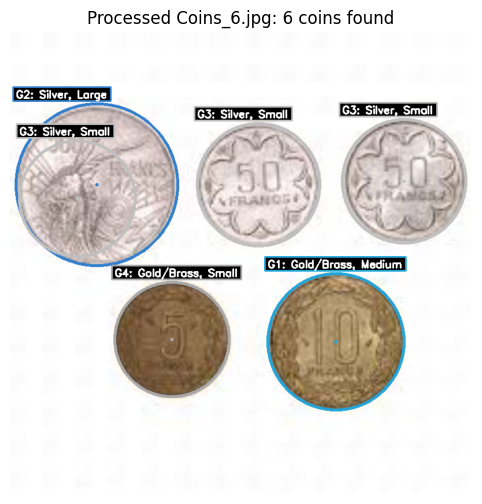

--- Processing: Coins_7.jpg ---
Detected 14 coins in Coins_7.jpg

COIN DETECTION & CLASSIFICATION SUMMARY

📊 TOTAL: 14 coins detected

📋 CLASSIFICATION BY GROUPS:
------------------------------------------------------------

 GROUP 1: 4 coins
      Size: Large
      Color: Silver
      Avg Diameter: 141.5 pixels
      Coin IDs: [1, 2, 3, 9]

 GROUP 2: 4 coins
      Size: Small
      Color: Silver
      Avg Diameter: 86.0 pixels
      Coin IDs: [4, 5, 7, 11]

 GROUP 3: 2 coins
      Size: Medium
      Color: Silver
      Avg Diameter: 106.0 pixels
      Coin IDs: [6, 14]

 GROUP 4: 2 coins
      Size: Small
      Color: Copper/Bronze
      Avg Diameter: 84.0 pixels
      Coin IDs: [8, 13]

 GROUP 5: 2 coins
      Size: Medium
      Color: Gold/Brass
      Avg Diameter: 118.0 pixels
      Coin IDs: [10, 12]

------------------------------------------------------------

🎨 By Color:
   Silver         : 10 coins (71.4%)
   Copper/Bronze  :  2 coins (14.3%)
   Gold/Brass     :  2 coins (14.3

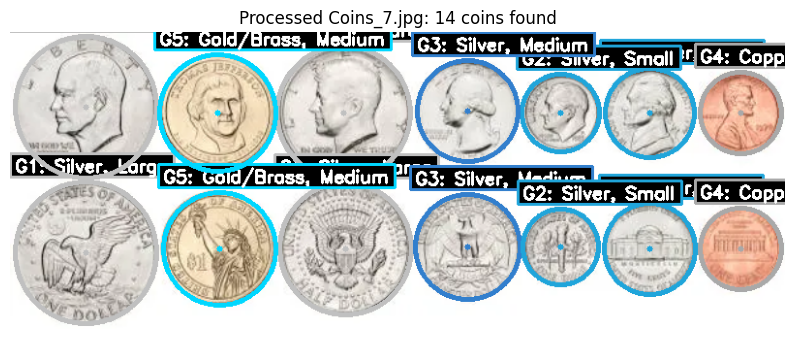

--- Processing: Coins_8.jpg ---
Detected 7 coins in Coins_8.jpg

COIN DETECTION & CLASSIFICATION SUMMARY

📊 TOTAL: 7 coins detected

📋 CLASSIFICATION BY GROUPS:
------------------------------------------------------------

 GROUP 1: 2 coins
      Size: Medium
      Color: Gold/Brass
      Avg Diameter: 179.0 pixels
      Coin IDs: [1, 6]

 GROUP 3: 2 coins
      Size: Large
      Color: Gold/Brass
      Avg Diameter: 194.0 pixels
      Coin IDs: [3, 7]

 GROUP 2: 1 coins
      Size: Small
      Color: Colored
      Avg Diameter: 168.0 pixels
      Coin IDs: [2]

 GROUP 4: 1 coins
      Size: Small
      Color: Gold/Brass
      Avg Diameter: 154.0 pixels
      Coin IDs: [4]

 GROUP 5: 1 coins
      Size: Medium
      Color: Colored
      Avg Diameter: 178.0 pixels
      Coin IDs: [5]

------------------------------------------------------------

🎨 By Color:
   Gold/Brass     :  5 coins (71.4%)
   Colored        :  2 coins (28.6%)

📏 By Size:
   Medium      :  3 coins (42.9%)
   Small   

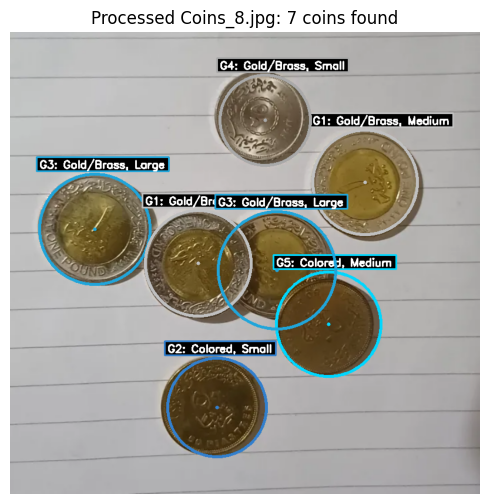

--- Processing: Coins_9.jpg ---
Detected 7 coins in Coins_9.jpg

COIN DETECTION & CLASSIFICATION SUMMARY

📊 TOTAL: 7 coins detected

📋 CLASSIFICATION BY GROUPS:
------------------------------------------------------------

 GROUP 1: 3 coins
      Size: Large
      Color: Gold/Brass
      Avg Diameter: 284.0 pixels
      Coin IDs: [1, 2, 3]

 GROUP 2: 1 coins
      Size: Medium
      Color: Copper/Bronze
      Avg Diameter: 266.0 pixels
      Coin IDs: [4]

 GROUP 3: 1 coins
      Size: Medium
      Color: Gold/Brass
      Avg Diameter: 270.0 pixels
      Coin IDs: [5]

 GROUP 4: 1 coins
      Size: Medium
      Color: Colored
      Avg Diameter: 264.0 pixels
      Coin IDs: [6]

 GROUP 5: 1 coins
      Size: Small
      Color: Gold/Brass
      Avg Diameter: 220.0 pixels
      Coin IDs: [7]

------------------------------------------------------------

🎨 By Color:
   Gold/Brass     :  5 coins (71.4%)
   Copper/Bronze  :  1 coins (14.3%)
   Colored        :  1 coins (14.3%)

📏 By Size:
 

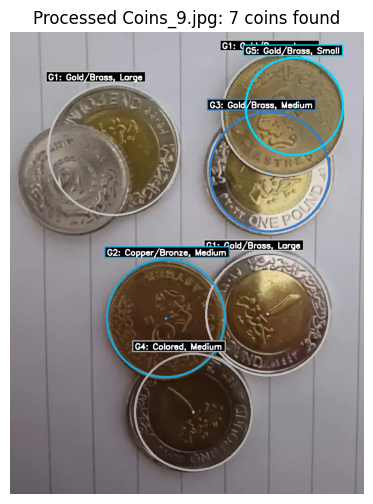

In [144]:
# Section 8 - Automated Folder Processing & Extraction
input_folder = "data"
output_folder = "output"
os.makedirs(output_folder, exist_ok=True)

valid_exts = (".jpg", ".jpeg", ".png")
images = [f for f in os.listdir(input_folder) if f.lower().endswith(valid_exts)]

for filename in images:
    path = os.path.join(input_folder, filename)
    print(f"--- Processing: {filename} ---")

    # 1. Detect
    img, circles = detect_coins(path)

    if circles is not None:
        img_name = os.path.splitext(filename)[0]
        img_dir = os.path.join(output_folder, img_name)
        os.makedirs(img_dir, exist_ok=True)

        # 2. Calculate dynamic thresholds for this image
        coin_list = [{'radius': c[2]} for c in circles]
        thresholds = get_dynamic_thresholds(coin_list)

        # 3. Extract Features (Now includes diameter_pixels)
        features = extract_coin_features(img, circles, thresholds)

        # 4. Group (Now includes avg_diameter)
        groups = group_similar_coins(features)

        # 5. Print Summary (Will now find 'avg_diameter')
        print_summary(features, groups)
        stats_img = create_stats_image(features, groups)

        # 6. Enhanced Extraction Loop with better cropping
        for i, coin in enumerate(features):
            x, y = coin['center']
            r = coin['radius']

            # Dynamic padding based on coin size (percentage of radius)
            pad_percentage = 0.15  # 15% padding around the coin
            pad = int(r * pad_percentage)

            # Ensure we don't go outside image boundaries
            y1 = max(0, y - r - pad)
            y2 = min(img.shape[0], y + r + pad)
            x1 = max(0, x - r - pad)
            x2 = min(img.shape[1], x + r + pad)

            # Extract coin with padding
            coin_crop = img[y1:y2, x1:x2]

            # Create a circular mask for cleaner extraction (optional)
            if coin_crop.size > 0:
                # Create a white background for better visibility
                h, w = coin_crop.shape[:2]
                center_crop = (r + pad, r + pad)  # Approximate center in cropped image

                # Save the cropped coin
                filename_coin = f"coin_{i+1}_{coin['color']}_{coin['size']}_r{coin['radius']}px.png"
                cv2.imwrite(os.path.join(img_dir, filename_coin), coin_crop)

                # Also save a masked version (coin with transparent background if needed)
                mask = np.zeros((h, w), dtype=np.uint8)
                cv2.circle(mask, (min(x - x1, w-1), min(y - y1, h-1)), r, 255, -1)

                # Apply mask to make background black
                masked_coin = cv2.bitwise_and(coin_crop, coin_crop, mask=mask)
                masked_filename = f"coin_{i+1}_{coin['color']}_{coin['size']}_masked.png"
                cv2.imwrite(os.path.join(img_dir, masked_filename), masked_coin)

        print(f"  ✓ Saved {len(features)} cropped coins to {img_dir}/")

        # 7. Final Output
        processed_img = annotate_image(img.copy(), features, groups)
        cv2.imwrite(os.path.join(img_dir, "_summary_annotated.jpg"), processed_img)

        plt.figure(figsize=(10, 6))
        plt.imshow(cv2.cvtColor(processed_img, cv2.COLOR_BGR2RGB))
        plt.title(f"Processed {filename}: {len(features)} coins found")
        plt.axis('off')
        plt.show()
    else:
        print(f"Skipping {filename}: No coins found.")